In [1]:
from pathlib import Path
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
colors = [ "#828282","#C8C8C8", "#292929"]
custom_cmap = sns.color_palette(colors)

## Combine rprop and CellCycle classification

In [3]:
in_path = '/Users/josefin/PhD/weihua_UHRF1_CellCycle/'

model = 'resnet18'

segmentation_subdirectory = 'results/segmentation_nuclei_IllCorr'

images_subdirectory = 'images/2603011/tif_IllCorr'

cellcycle_subdirectory = 'cellcycle_classification_retrained'

rprop_subdirectory = 'results/region_properties_nuclei_IllCorr'

In [4]:
mask_files = sorted((Path(in_path) / segmentation_subdirectory).glob('[!.]*.tif'))

image_files = sorted((Path((in_path + images_subdirectory)).glob('*ch0.tif')))

cellcycle_files = sorted((Path((in_path + cellcycle_subdirectory)).glob('*.csv')))

rprop_files = sorted((Path((in_path + rprop_subdirectory)).glob('*.csv')))


In [5]:
len(mask_files) == len(image_files) == len(cellcycle_files) == len(rprop_files)

len(mask_files), len(image_files), len(cellcycle_files), len(rprop_files)


(467, 467, 467, 467)

In [6]:
out_subdirectory = 'combined_IllCorr_retrained_' + model

outdir = Path(in_path) / out_subdirectory

if not outdir.exists():
    outdir.mkdir()

In [13]:
combined['max_class_name'].unique()

array(['G1G2', 'EarlyS', 'MidS', 'LateS', 'ambiguous'], dtype=object)

In [16]:
def calculate_sPhase_progression (df):
    df['s-phase_prog'] = np.nan
    df['s-phase_prog_corrected'] = np.nan
    df['s-phase-prob-sum'] = np.nan
    sphases = ['EarlyS', 'MidS', 'LateS']
    for idx, i in enumerate(df['max_class_name']):
        df.loc[idx, 's-phase-prob-sum'] = df['prob_EarlyS'][idx] + df['prob_MidS'][idx] + df['prob_LateS'][idx] + df['prob_G1G2'][idx] + df['prob_ambiguous'][idx]
        if i in sphases:
            df.loc[idx, 's-phase_prog'] = 0*df['prob_EarlyS'][idx] + 0.5*df['prob_MidS'][idx] + 1*df['prob_LateS'][idx]
            df.loc[idx, 's-phase_prog_corrected'] = 0 * (df['prob_EarlyS'][idx]/df['s-phase-prob-sum'][idx]) + 0.5 * (df['prob_MidS'][idx]/df['s-phase-prob-sum'][idx]) + 1*(df['prob_LateS'][idx]/df['s-phase-prob-sum'][idx])
        else:
            df.loc[idx, 's-phase_prog'] = np.nan


    return df


In [17]:
for cc_file, rprop_file in zip(cellcycle_files, rprop_files):

    cc_df = pd.read_csv(cc_file)

    prop_df = pd.read_csv(rprop_file)
    prop_df['cell_id'] = prop_df['label']

    combined = cc_df.merge(prop_df,
                        on=['cell_id', 'mask_file'],
                        )
                        
    combined = calculate_sPhase_progression(combined)

    combined['genotype'] = str()
    for idx, i in enumerate(combined['img_file']):
        if i.startswith('wt'):
            combined.loc[idx, 'genotype'] = 'wt'
        elif i.startswith('1G12'):
            combined.loc[idx, 'genotype'] = '1G12'
        elif i.startswith('1E3'):
            combined.loc[idx, 'genotype'] = '1_E3'

    # combined.to_csv(outdir / (rprop_file.stem + '_combined.csv'))

## Plot & Measure

In [18]:
outpath = '/Users/josefin/PhD/weihua_UHRF1_CellCycle/plots/'

In [19]:
all_combined_files = sorted(Path('/Users/josefin/PhD/weihua_UHRF1_CellCycle/results/combined_IllCorr_retrained_resnet18').glob('*.csv'))

for file in all_combined_files:
    df = pd.read_csv(file)
    df_resnet = pd.concat([df_resnet, df], ignore_index=True) if 'df_resnet' in locals() else df

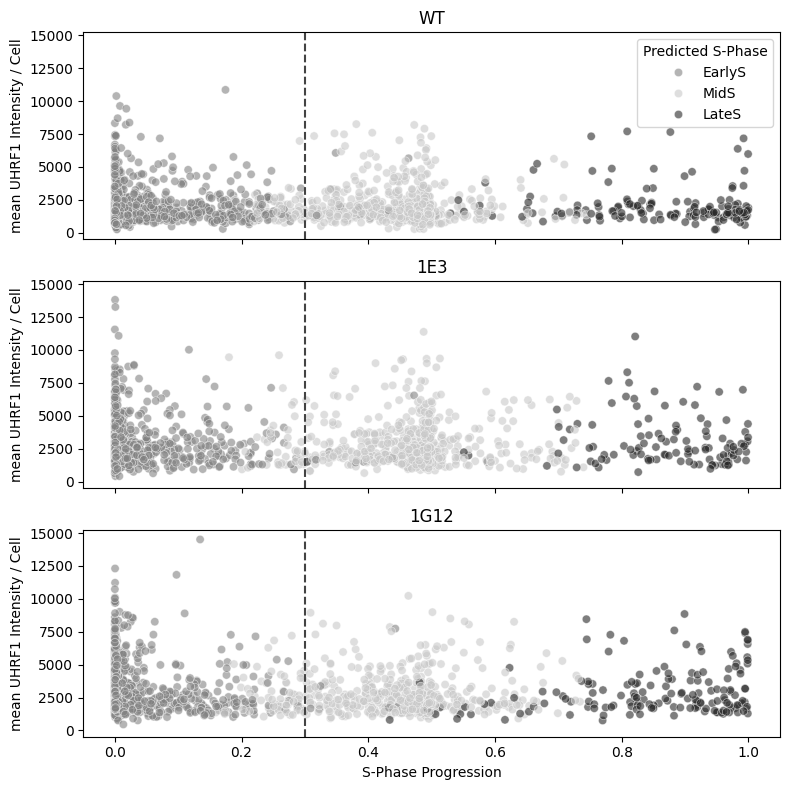

In [11]:
fig, ax = plt.subplots(3,1,figsize=[8,8], sharex=True, sharey=True)
sns.scatterplot(df_resnet[df_resnet['genotype'] == 'wt'], 
           x='s-phase_prog_corrected', y='intensity_mean', 
           palette=custom_cmap, hue='max_class_name', hue_order=['EarlyS', 'MidS', 'LateS'],
           legend=True, ax=ax[0], alpha=0.6)
sns.scatterplot(df_resnet[df_resnet['genotype'] == '1_E3'], 
           x='s-phase_prog_corrected', y='intensity_mean', 
           palette=custom_cmap, hue='max_class_name', hue_order=['EarlyS', 'MidS', 'LateS'],
           legend=False, ax=ax[1], alpha=0.6)
sns.scatterplot(df_resnet[df_resnet['genotype'] == '1G12'], 
           x='s-phase_prog_corrected', y='intensity_mean', 
           palette=custom_cmap, hue='max_class_name', hue_order=['EarlyS', 'MidS', 'LateS'],
           legend=False, ax=ax[2], alpha=0.6)
ax[0].legend(title='Predicted S-Phase')
ax[0].set_ylabel('mean UHRF1 Intensity / Cell')
ax[1].set_ylabel('mean UHRF1 Intensity / Cell')
ax[2].set_ylabel('mean UHRF1 Intensity / Cell')
ax[0].set_title('WT')
ax[1].set_title('1E3')
ax[2].set_title('1G12')
ax[2].set_xlabel('S-Phase Progression')
ax[0].axvline(0.3, linestyle='--', c="#434343")
ax[1].axvline(0.3, linestyle='--', c='#434343')
ax[2].axvline(0.3, linestyle='--', c='#434343')
plt.tight_layout()

# plt.savefig((outpath + 'meanInt_sphaseProg.png'), dpi=300, transparent=False)

In [ ]:
df_resnet['phase'] = str()
for idx, i in enumerate(df_resnet['s-phase_prog_corrected']):
    if i < 0.3:
        df_resnet.loc[idx, 'phase'] = 'early'
    elif i >= 0.3:
        df_resnet.loc[idx, 'phase'] = 'late'
    else:
        if np.isnan(i):
            max_class = df_resnet['max_class_name'][idx]
            if max_class == 'G1G2':
                df_resnet.loc[idx, 'phase'] = 'G1G2'
            else:
                df_resnet.loc[idx, 'phase'] = 'ambiguous'


,Unnamed: 0,cell_id,max_class,max_class_name,img_file,mask_file,prob_EarlyS,prob_G1G2,prob_LateS,prob_MidS,...,intensity_mean,intensity_min,intensity_max,intensity_std,img_file_rprop,s-phase_prog,s-phase_prog_corrected,s-phase-prob-sum,genotype,phase
1,1,2,3,MidS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.026025,0.081971,0.000012,0.877125,...,7311.506776,707.0,45991.0,4168.233342,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.438574,0.438574,1.0,1_E3,late
3,3,4,3,MidS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.003404,0.001593,0.000064,0.991914,...,5988.504343,847.0,27160.0,2992.953234,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.496021,0.496021,1.0,1_E3,late
4,4,5,0,EarlyS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.377740,0.257564,0.013213,0.091914,...,1247.021805,289.0,4740.0,514.657933,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.059170,0.059170,1.0,1_E3,early
5,5,6,0,EarlyS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.973081,0.024439,0.000005,0.000860,...,1990.617405,192.0,7569.0,1156.579697,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.000435,0.000435,1.0,1_E3,early
6,6,7,0,EarlyS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.977880,0.018565,0.000043,0.002320,...,1962.528250,204.0,9514.0,1221.810231,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.001203,0.001203,1.0,1_E3,early


In [ ]:
df_sphases = df_resnet[(df_resnet['phase'] == 'early') | (df_resnet['phase'] == 'late')]
df_sphases.head()

In [22]:
df_sphases_G1G2 = df_resnet[(df_resnet['phase'] == 'G1G2') | (df_resnet['phase'] == 'early') | (df_resnet['phase'] == 'late')]
df_sphases_G1G2.head()

,Unnamed: 0,cell_id,max_class,max_class_name,img_file,mask_file,prob_EarlyS,prob_G1G2,prob_LateS,prob_MidS,...,intensity_mean,intensity_min,intensity_max,intensity_std,img_file_rprop,s-phase_prog,s-phase_prog_corrected,s-phase-prob-sum,genotype,phase
0,0,1,1,G1G2,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.280250,0.717332,0.000012,0.000862,...,1864.835622,303.0,7778.0,813.405570,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,NaN,NaN,1.0,1_E3,G1G2
1,1,2,3,MidS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.026025,0.081971,0.000012,0.877125,...,7311.506776,707.0,45991.0,4168.233342,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.438574,0.438574,1.0,1_E3,late
2,2,3,1,G1G2,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.103539,0.872274,0.000341,0.000953,...,1328.388775,297.0,9603.0,753.396027,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,NaN,NaN,1.0,1_E3,G1G2
3,3,4,3,MidS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.003404,0.001593,0.000064,0.991914,...,5988.504343,847.0,27160.0,2992.953234,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.496021,0.496021,1.0,1_E3,late
4,4,5,0,EarlyS,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch1.tif,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch2_cp_mask...,0.377740,0.257564,0.013213,0.091914,...,1247.021805,289.0,4740.0,514.657933,1E3_UHRF1488_PCNA561_DAPI_001_pos0_ch0.tif,0.059170,0.059170,1.0,1_E3,early


In [25]:
df_sphases_G1G2 = df_sphases_G1G2.copy()

# Single wild-type mean (across all s-phases)
wt_global_median = (
    df_sphases_G1G2.loc[df_sphases_G1G2['genotype'] == 'wt', 'intensity_mean']
    .median()
)

# Normalize every row by that single value
df_sphases_G1G2.loc[:, 'intensity_norm_wt'] = (
    df_sphases_G1G2['intensity_mean'] / wt_global_median
)

# Grouped summary statistics
grouped = df_sphases_G1G2.groupby(['genotype', 'phase'])['intensity_norm_wt']
mean = grouped.mean().unstack()
sem = grouped.sem().unstack()



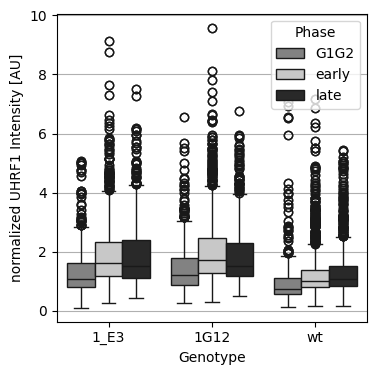

In [30]:
# df_sphases = df_resnet[(df_resnet['sphase'] == 'early') | (df_resnet['sphase'] == 'late')]

fig, ax = plt.subplots(figsize=(4,4))
plt.grid(True)
sns.boxplot(data=df_sphases_G1G2, x='genotype', y='intensity_norm_wt', hue='phase', hue_order=['G1G2', 'early', 'late'], 
            palette=custom_cmap, )
plt.xlabel('Genotype')
plt.ylabel('normalized UHRF1 Intensity [AU]')
plt.legend(title='Phase', loc='best');

# plt.savefig((outpath + 'mean_UHRF1_norm_boxplot1.pdf'), dpi=300, transparent=True)



In [15]:
df_sphases_rand_early = df_sphases[df_sphases['sphase'].isin(['early'])].sample(n=2040, random_state=42)

In [16]:
df_sphases_late = df_sphases[df_sphases['sphase'].isin(['late'])].sample(n=2040, random_state=42)

In [17]:
df_sphases_rand = pd.concat([df_sphases_rand_early, df_sphases_late], ignore_index=True)

/var/folders/7g/zlzzybjj2f31jz46mxnb71nw0000gn/T/ipykernel_20343/3106364422.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='S-Phase', loc='best');
/var/folders/7g/zlzzybjj2f31jz46mxnb71nw0000gn/T/ipykernel_20343/3106364422.py:7: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.swarmplot(


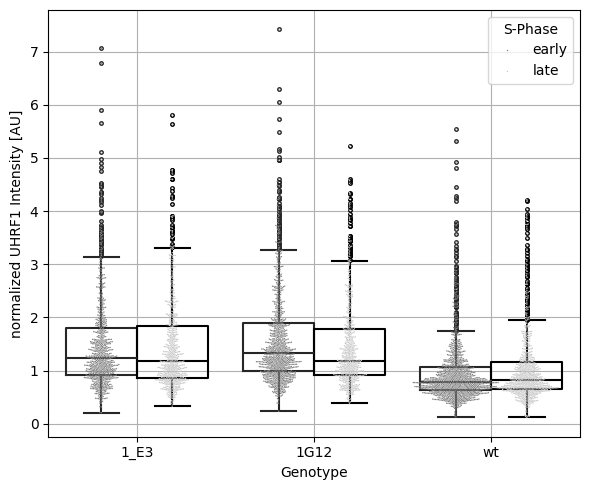

In [26]:

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_sphases, x='genotype', y='intensity_norm_wt', hue='sphase', hue_order=['early', 'late'], 
            palette='dark:black', fliersize=2.5, saturation=0.5, fill=False, linewidth=1.5, legend=False) 
plt.xlabel('Genotype')
plt.ylabel('normalized UHRF1 Intensity [AU]')
plt.legend(title='S-Phase', loc='best');
sns.swarmplot(
    data=df_sphases,
    x='genotype',
    y='intensity_norm_wt',
    hue='sphase',
    hue_order=['early', 'late'],
    palette=custom_cmap,
    size=1,
    ax=ax,
    dodge=True,
    edgecolor='black',

)

ax.grid(True)
ax.set_xlabel('Genotype')
ax.set_ylabel('normalized UHRF1 Intensity [AU]')
ax.legend(title='S-Phase', loc='best')

plt.tight_layout()
plt.grid(True)

plt.savefig(outpath + 'mean_UHRF1_norm_swarmplot.pdf', dpi=300, transparent=True)

# plt.savefig((outpath + 'mean_UHRF1_norm_boxplot1.pdf'), dpi=300, transparent=True)

In [19]:
classes = df_sphases.sphase.unique()

for cl in classes:
    print(len(df_sphases[df_sphases['sphase'] == cl]), cl)

2040 late
3062 early


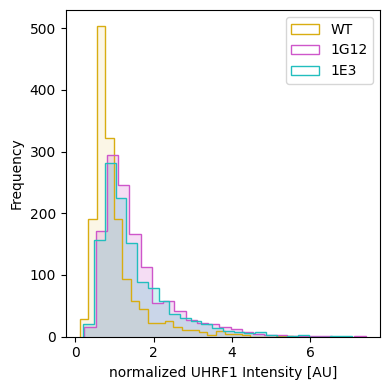

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == 'wt']['intensity_norm_wt'], bins=25, color="#D8AD11", alpha=0.1, histtype='bar')
plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == 'wt']['intensity_norm_wt'], bins=25, color="#D8AD11", alpha=1, label='WT', histtype='step')

plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == '1G12']['intensity_norm_wt'], bins=25, color="#CE56CA", alpha=0.2, histtype='bar')
plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == '1G12']['intensity_norm_wt'], bins=25, color="#CE56CA", alpha=1, label='1G12', histtype='step')

plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == '1_E3']['intensity_norm_wt'], bins=25, color="#22BEBE", alpha=0.2, histtype='bar')
plt.hist(df_sphases_rand[df_sphases_rand['genotype'] == '1_E3']['intensity_norm_wt'], bins=25, color="#22BEBE", alpha=1, label='1E3', histtype='step')

plt.xlabel('normalized UHRF1 Intensity [AU]')
plt.ylabel('Frequency')

plt.legend()

plt.tight_layout()
# plt.show()


# plt.savefig('/Users/josefin/PhD/weihua_UHRF1_CellCycle/plots/mean_UHRF1_norm_all_cmy.pdf', dpi=300, transparent=True)

## Statistics

In [21]:
from scipy.stats import mannwhitneyu
import itertools

results_sphase = []

for genotype in df_sphases['genotype'].unique():
    subset = df_sphases[df_sphases['genotype'] == genotype]
    sphases = subset['sphase'].unique()
    
    for s1, s2 in itertools.combinations(sphases, 2):
        g1 = subset[subset['sphase'] == s1]['intensity_mean']
        g2 = subset[subset['sphase'] == s2]['intensity_mean']
        
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        
        results_sphase.append((genotype, s1, s2, p))


In [22]:
results_vs_wt = []

for sphase in df_sphases['sphase'].unique():
    wt = df_sphases[
        (df_sphases['genotype'] == 'wt') #&
        # (df_sphases['sphase'] == sphase)
    ]['intensity_mean']

    for genotype in df_sphases['genotype'].unique():
        if genotype == 'wt':
            continue
        
        g = df_sphases[
            (df_sphases['genotype'] == genotype) #&
            # (df_sphases['sphase'] == sphase)
        ]['intensity_mean']
        
        stat, p = mannwhitneyu(wt, g, alternative='two-sided')
        
        results_vs_wt.append((sphase, genotype, p)) 


In [23]:
from statsmodels.stats.multitest import multipletests

pvals = [r[3] for r in results_sphase]
_, pvals_corr_sphase, _, _ = multipletests(pvals, method='fdr_bh')
pvals = [r[2] for r in results_vs_wt]
_, pvals_corr_vs_wt, _, _ = multipletests(pvals, method='fdr_bh')


In [24]:
def significance_label(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'ns'


In [25]:
# print("\nBetween S-phases")
# for r  in results_sphase:
#     print(f"{r[0]}: {r[1]} vs {r[2]} -> p={r[3]:.3e}")
#     print(significance_label(r[3]))
print("\nCORRECTED Between S-phases")
for r, p  in zip(results_sphase, pvals_corr_sphase):
    print(f"{r[0]}: {r[1]} vs {r[2]} -> p={p:.3e}")
    print(significance_label(p))

# print("\nGenotype vs WT")
# for r in results_vs_wt:
#     print(f"{r[0]}: WT vs {r[1]} -> p={r[2]:.3e}")
#     print(significance_label(r[2]))
print("\nCORRECTED Genotype vs WT")
for r, p  in zip(results_vs_wt, pvals_corr_vs_wt):
    print(f"{r[0]}: WT vs {r[1]} -> p={p:.3e}")
    print(significance_label(p))



CORRECTED Between S-phases
1_E3: late vs early -> p=2.174e-01
ns
1G12: early vs late -> p=6.156e-04
***
wt: early vs late -> p=2.160e-02
*

CORRECTED Genotype vs WT
late: WT vs 1_E3 -> p=9.921e-112
****
late: WT vs 1G12 -> p=1.000e-150
****
early: WT vs 1_E3 -> p=9.921e-112
****
early: WT vs 1G12 -> p=1.000e-150
****
